In [1]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt

In [ ]:
# Load the disk object

import sys
sys.path.append(r"d:\CPD_MPIA\Median_SNR")  # Add the module folder to Python path

import disk_residuals_median_SNR
DiskResiduals = disk_residuals_median_SNR.DiskResiduals_Median_SNR

import pickle

with open(r"d:\CPD_MPIA\all_disks.pkl", "rb") as f:
    all_disks = pickle.load(f)

# Print all attributes and their types
for disk_obj in all_disks:
    for key, value in disk_obj.__dict__.items():
        print(f"{key}: {type(value)}")

# To see all attribute names
print(list(disk_obj.__dict__.keys()))


rms_noise_FullFOV: <class 'NoneType'>
name: <class 'str'>
path: <class 'str'>
inc: <class 'float'>
PA: <class 'float'>
center: <class 'tuple'>
residuals: <class 'dict'>
clean_images: <class 'dict'>
clean_profile: <class 'dict'>
sigma_masks: <class 'dict'>
snr_maps: <class 'dict'>
sigma_masks_FullFOV: <class 'dict'>
snr_map_FullFOV: <class 'dict'>
distance_pc: <class 'int'>
disksize: <class 'dict'>
ringgap: <class 'numpy.ndarray'>
beam_info: <class 'dict'>
['rms_noise_FullFOV', 'name', 'path', 'inc', 'PA', 'center', 'residuals', 'clean_images', 'clean_profile', 'sigma_masks', 'snr_maps', 'sigma_masks_FullFOV', 'snr_map_FullFOV', 'distance_pc', 'disksize', 'ringgap', 'beam_info']


In [3]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
#AU = 1.496e13
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


In [4]:
def B_lambda(lam, T):
    """
    Planck function in wavelength (erg s^-1 cm^-2 Hz^-1 sr^-1)
    lam: wavelength in cm
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    return (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


def calculate_disk_properties(M_star = 1, Mp = 1, Mdot = 1e-5, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 195, 
                            mode="b", lam_mm=1.3e-1, 
                            T_ISM=10.0, Lplanet=1e-5, Lstar = 1.0,  mu=2.3, spec_flux  = None , show_results = False, Rout=None):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)

    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/yr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (Rjup)
    Rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    lam_mm : float
        Wavelength (mm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    mu : float
        Mean molecular weight

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # Turn input values to cgs
    # Disk parameters
    M_star = M_star * M_sun
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / sec_per_yr
    Rin = Rin * R_jup
    rp = rp * AU

    # Turn the luminosites to erg/s
    Lplanet = Lplanet * L_sun
    Lstar = Lstar * L_sun
    
    # 1. Create radial grid between Rin and Rout

    

    if Rout is None:
        Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)
    else:
        Rout = Rout * AU  # assume input Rout is in AU


    R = np.geomspace(Rin, Rout, 100)  # cm
    
    # 2. Calculate T_ext(R)
    #if mode == "b":
    #    L_irr = G * Mp * Mdot / (2.0 * R_p)
    #elif mode == "no_b":
    #    L_irr = 0.0
    #elif mode == "planet":
    #    L_irr = Lplanet
    #else:
    #    raise ValueError("mode must be 'b', 'no_b', or 'planet'")

    L_irr = G * Mp * Mdot / (2.0 * R_p)   # accretion luminosity
    
    #T_irr = 0.0 if L_irr == 0.0 else 
    
    T_irr = (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    
    #print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

    # Planet irradiation

    T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame

    # Star irradiation

    phi_flare = 0.02   # flaring angle of the host disk   (Huang et al. (2018b))

    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # K

    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25  # K
    # T_ext = (T_irr**4 + T_ISM**4)**0.25  # K
    
    # 3. Calculate T_eff(R)
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * 
            (1.0 - np.sqrt(Rin / R)))**0.25  # K
    
    # 4. Calculate Sigma(R)
    Rgas = 8.314e7  # erg/(mol K)
    
    # Sigma prescription 6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    
    # Sigma prescription 7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2
    
    # Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)
    
    # 5. Calculate T_c(R)
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rin / R))
    T_c = (A * f + T_ext**4)**0.25
    
    # 6. Calculate T_b(R)
    # Convert to arrays for consistent handling
    Sigma = np.asarray(Sigma, dtype=float)
    T_c = np.asarray(T_c, dtype=float)
    Teff = np.asarray(Teff, dtype=float)
    T_ext = np.asarray(T_ext, dtype=float)
    
    if not (Sigma.shape == T_c.shape == Teff.shape == T_ext.shape):
        raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")
    
    kappa_mm = 0.034*(0.87/lam_mm) 
    
    # τ_mm = 0.5 κ_mm Σ
    tau_mm = 0.5 * kappa_mm * Sigma
    
    # thin branch: Tb = 2 τ Tc
    Tb_thin = 2.0 * tau_mm * T_c
    
    # thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25
    
    # hard switch at τ=0.5
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    
    # 7. Calculate Tb_avg over the disc
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    num = np.sum(Tbmid * 2 * np.pi * Rmid * dR)
    den = np.pi * (Rout**2 - Rin**2)
    Tb_avg = num / den
    
    # 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area
    I_RJ = 2.0 * kB * Tb / (lam_mm*0.1)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
    F_nu = I_RJ  #np.pi  # erg s^-1 cm^-2 Hz^-1
    
    # Convert distance to cm and calculate flux
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm
    
    # Total emission from disk (before distance scaling)
    F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)   # erg s^-1 Hz^-1 (like Lν)

    # Observed flux at Earth (now include distance scaling)
    F_nu_obs = F_nu_tot / d_cm**2   # erg s^-1 cm^-2 Hz^-1

    # Convert to microJy just for reporting
    F_microJy = F_nu_obs / 1e-29    # µJy

    # In terms of dust mass (use observed flux!)
    #M_dust = (F_nu_obs * d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))

    M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g
    M_dust = M_dust / 5.972e27   # Earth masses

    if spec_flux is not None:
        M_dust_source = spec_flux*1e-29* (d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))
        M_dust_source = M_dust_source / 5.972e27   # earth mass
        print(f'M_dust_source = {M_dust_source} M_earth')
    
    if show_results:
        print(f'Rout = {Rout/AU:.2f} au')
        print(f'Tb_avg = {Tb_avg:.1f} K')
        print(f'F_nu_tot = {F_microJy:.2f} microJy')
    
    
    return {
        'R': R,
        'Rout': Rout / AU,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Teff': Teff,
        'T_c': T_c,
        'Tb': Tb,
        'Sigma': Sigma,
        'tau_mm': tau_mm,
        'F_nu_tot': F_microJy,
        'Tb_avg': Tb_avg,
        'M_dust': M_dust,
        'T_irr': T_irr,
        'T_irr_p': T_irr_p,
        'T_irr_star': T_irr_star
    }




In [5]:
# Correction code in order to add all the heating sources together

# Equation 1: viscous heating included anyways
# Equation 2: Accretion heating is embedded  within T_ext
# Planet irradiation added into T_irr as an extra luminosity source (Eq 2 from Andrews paper in Appendix D)
# Andrews Paper do like this:

In [6]:
def plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label, save_plots=False):
    """
    Plot CPD surface density and temperature profiles,
    including brightness temperature overlays for 0.85mm and 3mm.

    Parameters
    ----------
    results : dict
        Dictionary returned by calculate_disk_properties (main wavelength).
    results_tb_085 : dict
        Dictionary for Tb at 0.85mm.
    results_tb_3 : dict
        Dictionary for Tb at 3mm.
    alpha : float
        Viscosity parameter for annotation.
    Mp_label : str
        Planet mass label for annotation.
    Mdot_label : str
        Accretion rate label for annotation.
    save_plots : bool
        Whether to save plots to file.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: log10(Sigma) vs log10(R/AU)
    ax1.plot(np.log10(results['R_AU']), np.log10(results['Sigma']), color='k')
    ax1.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax1.set_ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$')
    
    ax1.set_xlim(-3.6, 0.5)
    #ax1.set_ylim(1.5, 4.3)

    # Panel 2: log10(Temperature) vs log10(R/AU)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['Teff']), color='b', label=r'$T_{\rm eff}$', linewidth=2)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['T_c']), color='r', label=r'$T_c$', linewidth=2)
    ax2.plot(np.log10(results_tb_085['R_AU']), np.log10(results_tb_085['Tb']), 'k--', label=r'$T_b(0.85\,\mathrm{mm})$', linewidth=2)
    ax2.plot(np.log10(results_tb_3['R_AU']), np.log10(results_tb_3['Tb']), 'k:', label=r'$T_b(3\,\mathrm{mm})$', linewidth=2)
    ax2.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax2.set_ylabel(r'$\log_{10}T\,(\mathrm{K})$')
    ax2.set_xlim(-3.6, 0.5)
    #ax2.set_ylim(0.0, 4.5)
    #ax2.set_title(r'Circumplanetary disc detection', loc='center', fontsize=20)
    ax2.annotate(f'{Mp_label}\n{Mdot_label}\n$\\alpha = {alpha}$',
                 xy=(-0.9, 4.2), xycoords='data', fontsize=13,
                 bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="gray", alpha=0.7))
    ax2.legend(loc='lower left', fontsize=12, frameon=False)


    plt.tight_layout()
    if save_plots:
        plt.savefig('cpd_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()


kappa_mm_dict = {                       
    "0.85mm": 0.034 * (0.87/0.85)**1.7,    # Input: 0.85mm → Output: 0.036 cm^2/g
    "1.3mm": 0.034 * (0.87/1.3)**1.7,      # Input: 1.3mm → Output: 0.018 cm^2/g  
    "3mm": 0.034 * (0.87/3)**1.7,          # Input: 3mm → Output: 0.0024 cm^2/g
    "10mm": 0.034 * (0.87/10)**1.7         # Input: 10mm → Output: 0.00024 cm^2/g
}




In [7]:
# Plotting the different temperatue components

def plot_temperature_components(results, Mp_label, Mdot_label, save_plot=False):
    """
    Plot the different temperature components in the disk.

    Parameters
    ----------
    results : dict
        Dictionary containing the results from the disk model.
    Mp_label : str
        Label for the planet mass.
    Mdot_label : str
        Label for the accretion rate.
    save_plot : bool
        Whether to save the plot to a file.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plotting the temperature components
    ax.plot(results['R_AU'], results['T_ext'], label=r'$T_{\rm ext}$', color='k')
    ax.plot(results['R_AU'], results['T_irr'], label=r'$T_{\rm irr (accretion)}$', color='b')
    ax.axhline(y= results['T_irr_star'], color='gray', linestyle='--', label=r'$T_{\rm irr, star}$')
    ax.plot(results['R_AU'], results['T_irr_p'], label=r'$T_{\rm irr, p}$', color='g')
    ax.plot(results['R_AU'], results['Teff'], label=r'$T_{\rm eff  (viscous)}$', color='orange')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r'$R/\mathrm{AU}$', fontsize=14)
    ax.set_ylabel(r'$T\,(\mathrm{K})$', fontsize=14)
    ax.set_title('Temperature Components in the Disk', fontsize=16)
    ax.legend(fontsize=12)

    plt.tight_layout()
    if save_plot:
        plt.savefig('temperature_components.png', dpi=300, bbox_inches='tight')
    plt.show()

Given alpha = 0.0001, Rout = 1.86 au, MpMpdot = 1e-5:
for 1.3 mm:

for 0.85 mm:

for 3 mm:


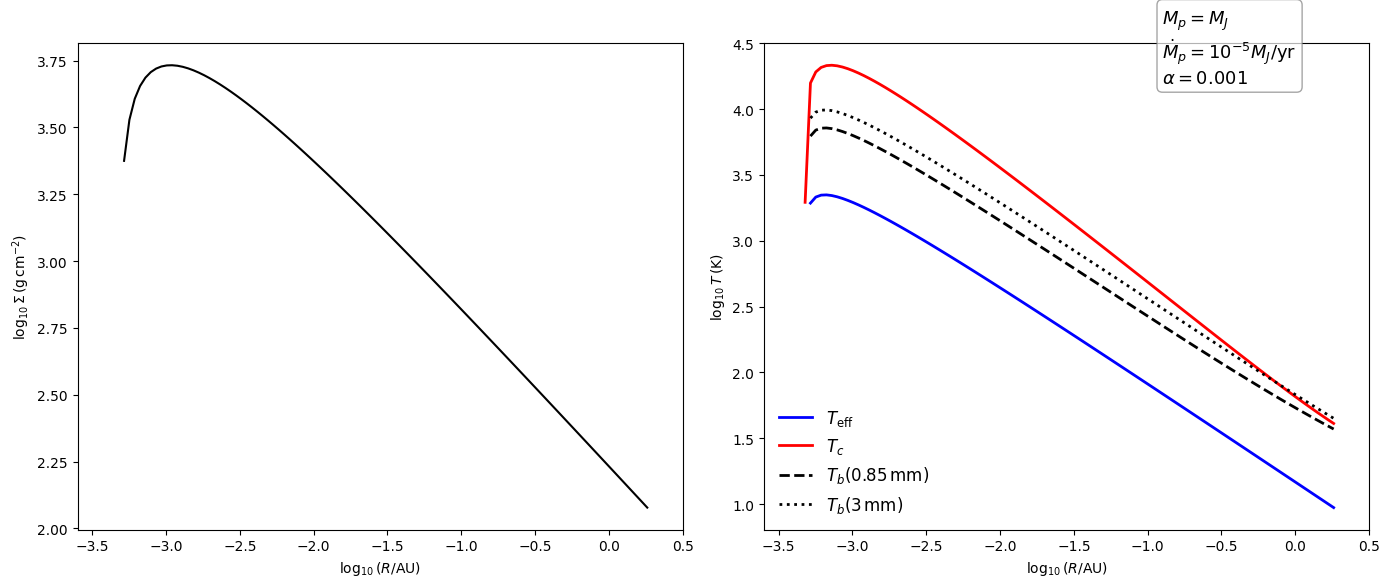

In [8]:
# Example usage with your parameters
if __name__ == "__main__":

    # Disk parameters
    Mp = 1.0 
    Mdot = 1e-5 
    alpha = 1e-3
    kappaR = 10.0
    Rin = 1.0 
    Rout = 1.85 
    d = 140

    Mp_label = r'$M_p = M_J$'
    Mdot_label = r'$\dot{M}_p = 10^{-5} M_J/\mathrm{yr}$'
    print(f'Given alpha = 0.0001, Rout = 1.86 au, MpMpdot = 1e-5:')
    # Calculate for main wavelength (e.g., 1.3mm)
    print(f'for 1.3 mm:')
    results = calculate_disk_properties(Mp = Mp , Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                        lam_mm=1.3)
    # Calculate for 0.85mm
    print(f'\nfor 0.85 mm:')
    results_tb_085 = calculate_disk_properties(Mp = Mp, Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                               lam_mm=0.85)
    # Calculate for 3mm
    print(f'\nfor 3 mm:')
    results_tb_3 = calculate_disk_properties(Mp = Mp, Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                             lam_mm=3)

    # Plot
    plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label)

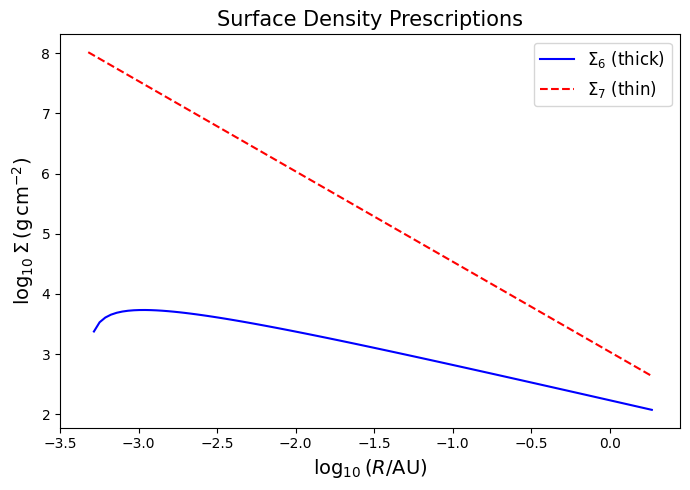

In [9]:
def plot_sigma6_vs_sigma7(Mp, Mdot, alpha, kappaR, Rin, Rout, mu=2.3):
    """
    Plot Sigma6 (optically thick) vs Sigma7 (optically thin) as a function of radius.

    """
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / sec_per_yr
    Rin = Rin * R_jup
    Rout = Rout * AU

    

    R = np.geomspace(Rin, Rout, 100)
    # Sigma6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)

    # Sigma7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    # For plotting, use T_ext = 10 K (ISM) as a simple reference
    T_ext = 10.0
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)

    plt.figure(figsize=(7,5))
    plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')
    plt.plot(np.log10(R/AU), np.log10(Sigma7), label=r'$\Sigma_7$ (thin)', color='r', linestyle='--')
    plt.xlabel(r'$\log_{10}(R/\mathrm{AU})$', fontsize=14)
    plt.ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$', fontsize=14)
    plt.title('Surface Density Prescriptions', fontsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_sigma6_vs_sigma7(1, 1e-5, 1e-3, 10, 1, 1.85)

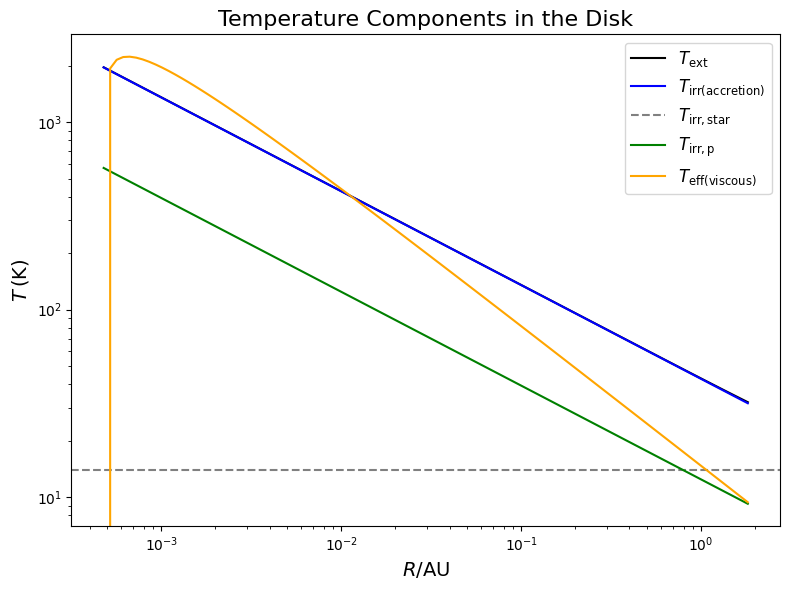

In [10]:
results = calculate_disk_properties(Mp = Mp , Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                        lam_mm=1.3)
plot_temperature_components(results,  r'$M_p = M_J$', r'$\dot{M}_p = 10^{-5} M_J/\mathrm{yr}$', save_plot=False)

In [11]:
# Try importing it onto the CPD measurements to plot flux versus dust size 

# xcentroid ycentroid area max_value radius_au   (r90 = 72.9 AU)
# 1435.2160509756225 1343.8993475502016 470.0 5.076771442864703 165.37302792026688

# essentially estimate of flux for different disk radius
# what paremeters can be fixed? 
# obseved frequency of exoalma is 331.6 GHz （0.9 mm) from table 1 of exoalma
# R_out varies but R_out is a function of Mp and Mdot 
# total flux in the beam is 294.94 micro Jy

trial = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3)


result = calculate_disk_properties(1.52, Mp, Mdot, 0.1, kappaR, 1, 165, 195, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3)
    F_nu_tot = result['F_nu_tot']


for 0.9 mm (exoALMA observing wavelength):




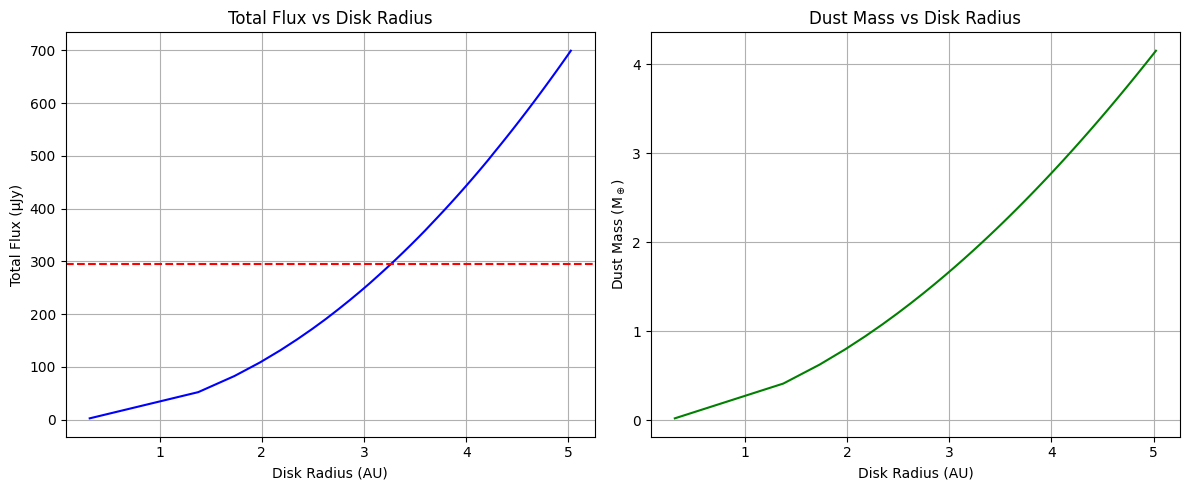

In [12]:
# the catalog show the signal to noise maximum value , not the maximum mu Jy so maybe need change the code a bit 

# Now create an array to vary Mp from 1 to 20 M_jup 
# Obtain an array of F_nu_tot and plot the plot 

# dust mass for the source: 
print(f'for 0.9 mm (exoALMA observing wavelength):')
# spec_flux=294.94

M_dust_source = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=1e-5, mu=2.3, spec_flux=None)


print(f'\n')

Mp_array = np.linspace(0.001, 4, 50)  # from 1 to 13 M_jup (limit of brown dward)
F_nu_tot_array = []
Rout_array = []
M_dust_array = []



for Mp in Mp_array:
    result = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=1e-5, mu=2.3)
    F_nu_tot = result['F_nu_tot']
    F_nu_tot_array.append(F_nu_tot)
    Rout = result['Rout']
    Rout_array.append(Rout)
    M_dust = result['M_dust']
    M_dust_array.append(M_dust)

# Plotting side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(Rout_array, F_nu_tot_array, color='blue')
ax1.set_xlabel('Disk Radius (AU)')
ax1.set_ylabel('Total Flux (μJy)')
ax1.set_title('Total Flux vs Disk Radius')
ax1.axhline(y=294.94, color='red', linestyle='--')
ax1.grid()

ax2.plot(Rout_array, M_dust_array, color='green')
ax2.set_xlabel('Disk Radius (AU)')
ax2.set_ylabel('Dust Mass (M$_\oplus$)')
ax2.set_title('Dust Mass vs Disk Radius')
#ax2.axhline(y=1.0895471654752764e-09, color='red', linestyle='--')
ax2.grid()

plt.tight_layout()
plt.show()


In [13]:
print(52266/470)

111.20425531914894


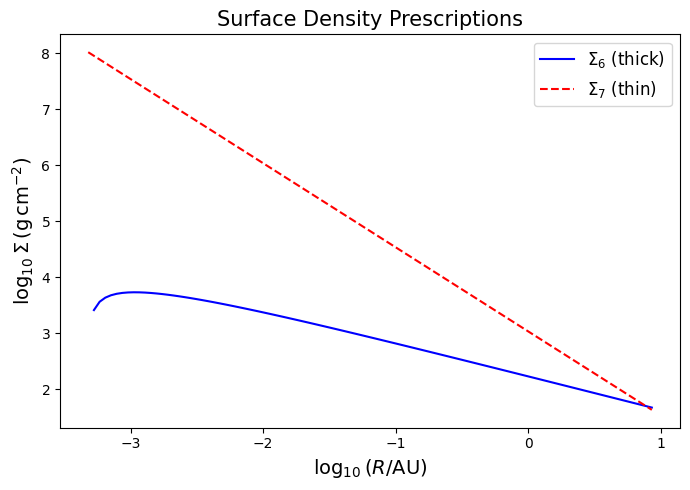

In [14]:
plot_sigma6_vs_sigma7(1, 1e-5, 1e-3, 10, 1, 8.59, mu=2.3)




In [15]:
# Plot parameter comparisons
# For a fix flux, what are the possible combinations of Mp, Mdot, Disk Radius 
# Input flux and a grid of Mp -> output Mdot for each Mp 
# Alter the spec flux function a little bit
# Conceptually how to reverse eveything 


### Plot the zhu model parameter space

In [22]:


def zhu_plots( target_flux=294, tolerance=3, disk_arr=0, rp=165):
    """
    Parameter space plots for CPD models based on Zhu et al. (2018)
    -----------
    Input Parameters (fixed within function):
    -----------
    alpha_grid : the viscosity parameter grid
    Mp_grid : the planet mass grid (M_jup)
    Mdot_grid : the accretion rate grid (M_jup/yr)

    -----------
    Variable Parameters:
    -----------
    target_flux : Upper limit flux for the CPD (muJy)
    tolerance : the tolerance for matching the target flux (muJy)
    disk_arr: Array of disk properties [disk_name, Stellar mass (M_sun), distance to the system (pc) , Lstar (L_sun)]
    rp : radius of the flux (au)

    """
    alpha_grid = [1e-4, 1e-3, 1e-2]
    Mp_grid = np.logspace(-3, 1, 150)
    Mdot_grid = np.logspace(-8, -5, 150)

    from matplotlib import cm
    from joblib import Parallel, delayed
    cmap = cm.viridis
    colors = [cmap(i) for i in np.linspace(0, 1, len(alpha_grid))]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

    def run_model(Mp, Mdot, alpha):
        out = calculate_disk_properties(
            M_star=disk_arr[1], Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=rp, d_pc=disk_arr[2],
            mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, Lstar=disk_arr[3], mu=2.3
        )
        if abs(out['F_nu_tot'] - target_flux) < tolerance:
            return (alpha, Mp, Mdot, out['Rout'], out['F_nu_tot'])
        return None

    # Run in parallel for all alpha values
    results = Parallel(n_jobs=-1)(
        delayed(run_model)(Mp, Mdot, alpha)
        for alpha in alpha_grid
        for Mp in Mp_grid
        for Mdot in Mdot_grid
    )
    results = [r for r in results if r is not None]

    # Plotting
    for idx, alpha in enumerate(alpha_grid):
        arr = [r for r in results if r[0] == alpha]
        if arr:
            arr = np.array(arr)
            label = f'α={alpha:.0e}'
            axes[0].plot(arr[:, 1], arr[:, 2], color=colors[idx], label=label)
            axes[1].plot(arr[:, 1], arr[:, 3], color=colors[idx], label=label)
            axes[2].plot(arr[:, 2], arr[:, 3], color=colors[idx], label=label)

    fig.suptitle(f"{disk_arr[0]}, ($R$ = {rp} AU)", fontsize=20, y=1.05)

    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Planet Mass (M_jup)')
    axes[0].set_ylabel('Accretion Rate (M_jup/yr)')
    axes[0].set_title('Mp vs Mdot')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_xscale('log')
    axes[1].set_xlabel('Planet Mass (M_jup)')
    axes[1].set_ylabel('Disk Radius (AU)')
    axes[1].set_title('Mp vs Rout')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].set_xscale('log')
    axes[2].set_xlabel('Accretion Rate (M_jup/yr)')
    axes[2].set_ylabel('Disk Radius (AU)')
    axes[2].set_title('Mdot vs Rout')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

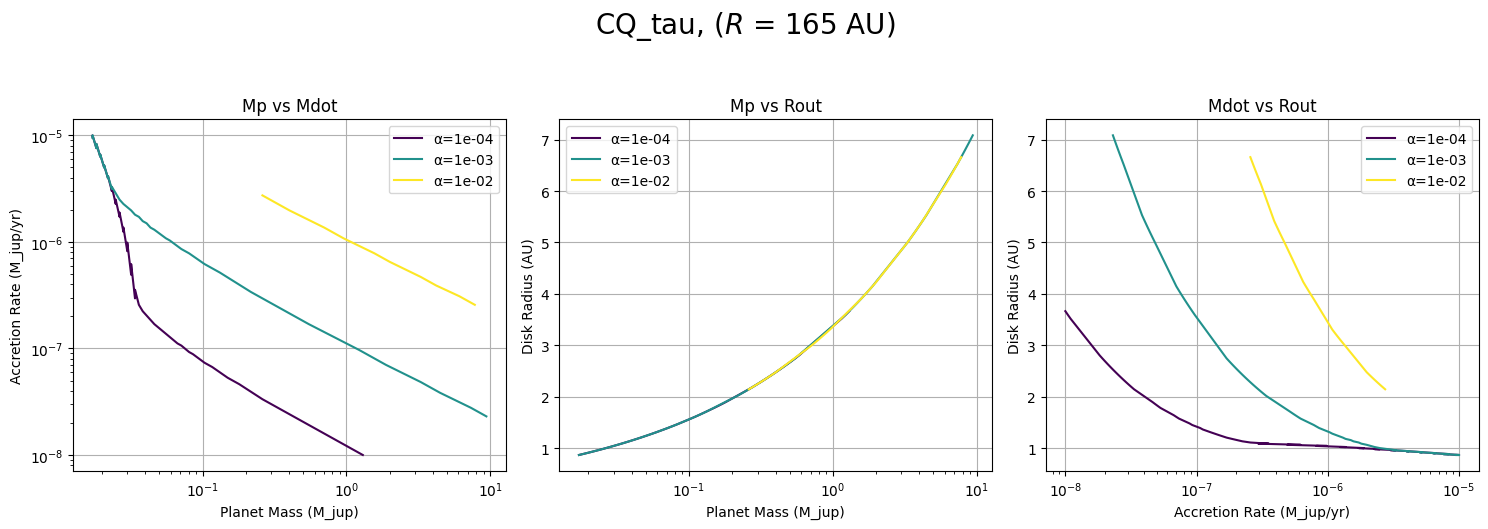

In [23]:
# Plot the temperature components for each case too 

# Do this for the 4 candidates

CQ_tau_disk_arr = ["CQ_tau", 1.4, 149, 10]
zhu_plots( target_flux=294, tolerance=3, disk_arr=CQ_tau_disk_arr, rp=165 )


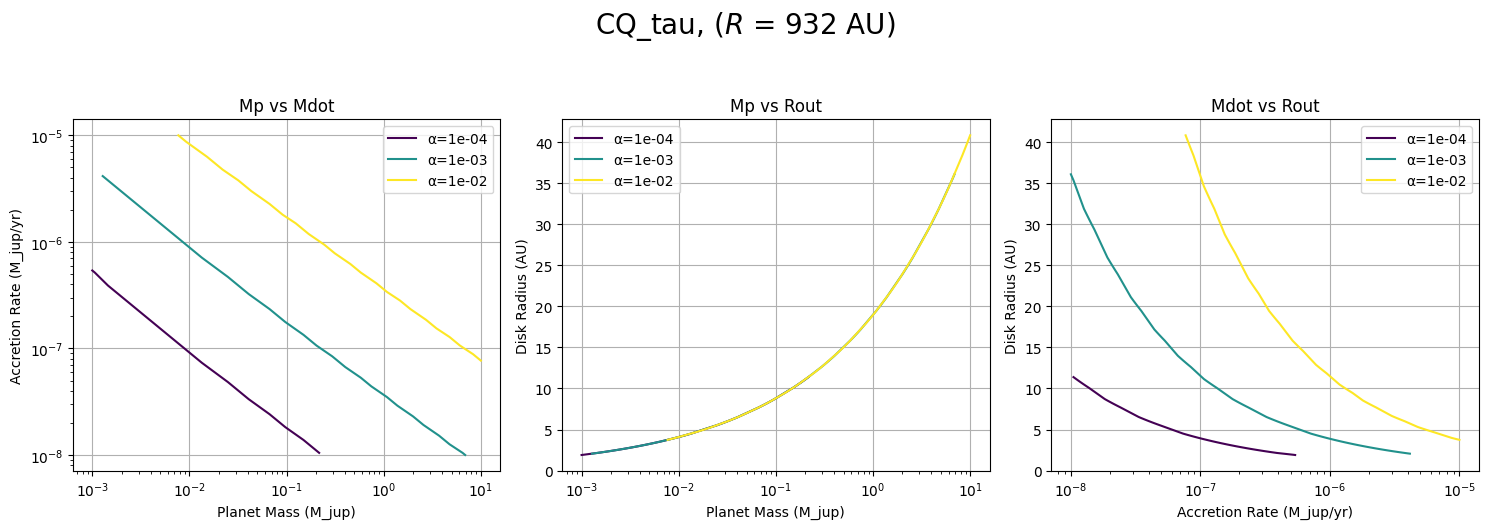

In [24]:
zhu_plots( target_flux=252, tolerance=3, disk_arr=CQ_tau_disk_arr, rp=932 )

#### Notes from the plot

With high viscosity, the range of acceretion rate is higher because 
The surface density is small at high viscosity for a given Mdot , so flux comes from heating domination (temperature not sigma) , so the scaling of MpMdot form L_irr is shown as linear here.
For low viscosity, sigma is large so at very low Mp , irradiation term (MpMdot) is too small and Mdot has to shoot up to compensate flux via surface density term .

### Check model consistency with Andrews HD143006

Measure the flux limit at the innergap of the disk and try to obtain the same planet properties. Relevant to table 3 and table 4  - try to reproduce table 4.
since the observation is made in different wavelengths, I will take the flux he measured at the wavelength and the location of the gap, plug into my model to plot the radius versus planet mass for D22 and D51 gap. 

1. Change the gap location unit from mas to au (au = mas *dc/1000)
2. Makesure flux is in value of microJy (take the range of flux values for each recovery fraction to verify as it would make it more convenient for me if I want to do CPD injection recovery too) 
3. Plot them


*Note: the observing frequency is 240 GHz which is 1.25 mm , the wavelength-dependent opacity is 2.4 cm^2/g*


Okay , so the situation now is that , the contour levels should be changed into recovery fractions (if present) or sigma levels , the one overlaying line should be the ALMA angular resolution,  representing the locus of CPD parameters where the CPD angular size equals the beam: theta_cpd = Rcpd/d = theta_ALMA, therefore y axis (Rcpd/RHill) = theta_beam*d/RHill , where RHill depends on Mp. so thats the contour line that shows below which the CPD is unresolved. 
without the recovery fractions...what is the minimum flux? should I keep the whole recovery fraction relevant relation as an if case? 




In [174]:




def zhu_plots_flux_map(target_flux_arr, disk_arr=None, rp=165, lam_mm=1.25, alpha=1e-3, plotmass=True , color = '5sigsource'):
    """
    Make a DSHARP-style 2D flux map: 
    - x-axis: log10(Mp/Mjup)
    - y-axis: Rcpd / RHill -> normalised disk outer radius
    - shading: log10(Fnu [µJy]) or log10(M_dust [M_earth])
    - contours: recovery flux thresholds

    Parameters
    ----------
    target_flux_arr : list
        Flux thresholds (µJy) for contour level.
    disk_arr : list
        [disk_name, M_star (Msun), distance (pc), Lstar (Lsun)]
    rp : float
        Planet orbital radius (AU).
    lam_mm : float
        Observing wavelength in mm.
    alpha : float
        Viscosity parameter.
    """
    if disk_arr is None:
        disk_arr = ["Unknown", 1.0, 100, 1.0]

    # Grids
    Mp_grid = np.logspace(-2, 1, 80)       # 0.01 - 10 Mjup
    Rout_frac_grid = np.linspace(0.05, 0.8, 60)  # fraction of RH   -> w
    M_star_jup = disk_arr[1] * 1047.56     # convert Msun to Mjup for explicit RHill calc

    # Array of flux with 2D shape ( Rout_frac, Mp)
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_dust = np.zeros((len(Rout_frac_grid), len(Mp_grid)))

    # Compute flux grid , for value combination in Rout and MP
    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):
            RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
            print(f'Calculating for Mp = {Mp:.3f} Mjup, Rout_frac = {frac:.3f} -> RHill = {RHill:.2f} au')
            Rout = frac * RHill
            out = calculate_disk_properties(
                M_star=disk_arr[1], Mp=Mp, Mdot=1e-6, alpha=alpha,  # pick fiducial Mdot
                kappaR=2.4, Rin=1, rp=rp, d_pc=disk_arr[2],
                mode="b", lam_mm=lam_mm, T_ISM=10.0, Lplanet=1e-5,
                Lstar=disk_arr[3], mu=2.3, Rout=Rout
            )
            Flux_vals[i, j] = out['F_nu_tot']
            # Mcpd in Jupiter mass
            M_dust[i,j] = out['M_dust'] / 317.8  # convert Earth mass to Jupiter mass

    # Mask out flux values below the minimum target flux (or 1 sigma level )
    min_flux = min(target_flux_arr) # µJy
    masked_Flux_vals = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    masked_M_dust = np.where(Flux_vals >= min_flux, M_dust, np.nan)

    sigma_ujy = target_flux_arr[0]  # Base noise level in µJy
    sigma_levels = [1, 2, 3, 5]  # Sigma multiples to show
    flux_levels = [n * sigma_ujy for n in sigma_levels]  # Actual flux thresholds
    
    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # color scheme

    if color == '5sigsource':
        cmap = 'Blues'
    elif color == 'planet':
        cmap = 'Greens'
    elif color == 'external':
        cmap = 'Purples'


    if plotmass:
        vmin = np.nanmin(np.log10(masked_M_dust))
        vmax = np.nanmax(np.log10(masked_M_dust))
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(masked_M_dust),
            levels=np.linspace(vmin, vmax, 7), cmap=cmap, extend='both'
        )
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm dust}/M_{\rm Jup})$', fontsize=11)
    else:
        # Use linear flux levels for filled contours
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=flux_levels, cmap=cmap, extend='both'
        )
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    cs = ax.contour(
        np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
        levels=flux_levels,
        colors='black', linewidths=1.5, linestyles='dashed', alpha=0.8
    )
    # Label contours with sigma notation
    labels = [f'{n}σ' for n in sigma_levels]
    fmt = {level: label for level, label in zip(flux_levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)
        

    # Overlay ALMA angular resolution limit
    theta_beam = disk_arr[4]  # arcsec
    d_pc = disk_arr[2]
    # For each Mp, calculate the  Rout_frac = theta_beam * d_pc / RHill
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    Rout_frac_beam =  (theta_beam * d_pc)/ (2*RHill_arr)  # this seems to give overestimation ,(theta_beam * d_pc)
    # for each planet mass, or for each Rout give a Mp 
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', linestyle='-', linewidth=2, label='ALMA detection limit')
    print(f'Min Rout_frac for ALMA detection limit: {np.min(Rout_frac_beam):.3f}')


    # Axis labels
    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(0.1, 0.8)

    # Colorbar

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}, κ=2.4 cm²/g")

    plt.tight_layout()
    plt.show()

In [175]:
# Save all the  disk properties in disk_arr

# disk_arr = [disk_name, M_star (Msun), distance (pc), Lstar (Lsun), beam (arcsec)]


disk_arr = {
    "AA_Tau":      ["AA_Tau", 0.79, 145, 1.1, 0.12],
    "CQ_Tau":      ["CQ_Tau", 1.4, 149, 10, 0.135],
    "DM_Tau":      ["DM_Tau", 0.45, 144, 0.24, 0.134],
    "HD_34282":    ["HD_34282", 1.61, 309, 108, 0.106],
    "HD_135344B":  ["HD_135344B", 1.61, 135, 6.7, 0.26],
    "HD_143006":   ["HD_143006", 1.56, 167, 3.8, 0.226],
    "J1604":       ["J1604", 1.29, 112, None, 0.257],
    "J1615":       ["J1615", 1.14, 156, None, 0.303],
    "J1842":       ["J1842", 1.07, 151, 0.8, 0.235],
    "J1852":       ["J1852", 1.03, 147, 0.6, 0.236],
    "LkCa_15":     ["LkCa_15", 1.14, 156, 1, 0.131],
    "MWC_758":     ["MWC_758", 1.4, 151, 10.4, 0.241],
    "PDS_66":      ["PDS_66", 1.28, 98, 1.2, 0.234],
    "SY_Cha":      ["SY_Cha", 0.77, 182, None, 0.178],
    "V4046_Sgr":   ["V4046_Sgr", 1.73, 72, 0.5, 0.241],
}

In [176]:
# Changes to made 
# set the contours as the sigma levels 
# Add the reference , maybe in mass by integration
# And also for all the sources
# And then the methodology outline ( 300 to 500 words )
#for {Disk_name} in  _disk_arr:
  #  sigma_file = /Disk_Residual_Profile_Median_SNR/{Disk_name}/ {Disk_name}__residual_profileFullFOV_robust2.0.txt 
    # turn from sigma (jy/beam) to flux (mJy) after macting the input r location






Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.28 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.29 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.31 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.32 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.33 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.34 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 0.35 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 0.36 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 0.37 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 0.38 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 0.40 au
Calculating for Mp = 0.031 Mjup, Rout_frac = 0.050 -> RHill = 0.41 au
Calculating for Mp =

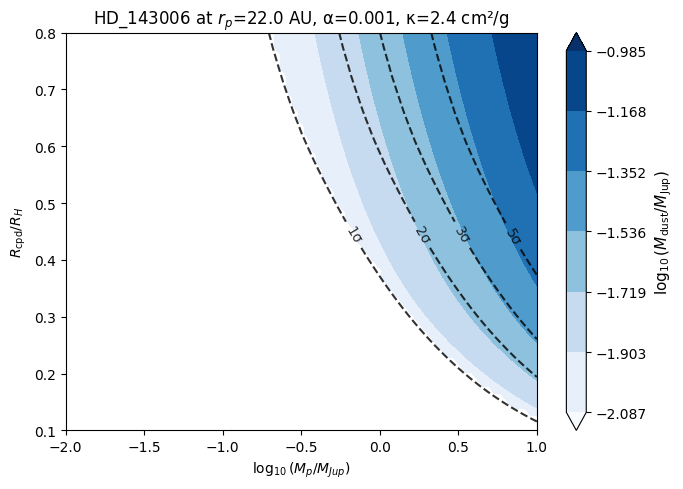

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.65 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.67 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.69 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.71 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.73 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.75 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.77 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.79 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 0.82 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 0.84 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 0.87 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 0.89 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 0.92 au
Calculating for Mp = 0.031 Mjup, Rout_frac = 0.050 -> RHill = 0.94 au
Calculating for Mp =

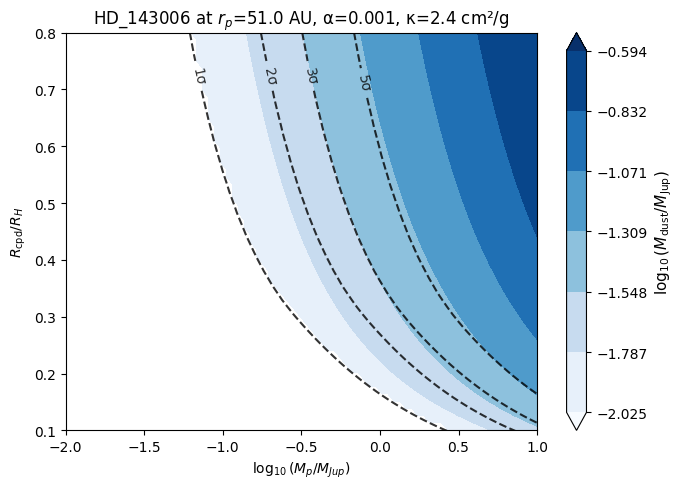

In [177]:
# Gap of HD143006 from Andrews paper
# D22:  103 (mas for r_peak), 
# D51  : 338 (mas for r_peak),

HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]

HD1423006_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

# Run for the D22 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=disk_arr["HD_143006"],
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-3,
    plotmass=True,
)

# Run for the D51 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=disk_arr["HD_143006"],
    rp=rD51,
    lam_mm=1.25,
    alpha=1e-3
)

# Plot for 5 sigma sources


In [178]:

five_sigma_sources = [
    # Format: [disk_name, radius_au, flux_ujy, sigma_flux_ujy]
    ["CQ_Tau", 165.37, 260.30, 45.81],
    ["CQ_Tau", 932.14, 222.35, 40.25],
    ["DM_Tau", 1845.47, 5422.67, 161.82],
    ["V4046_Sgr", 837.63, 90.54,22.22],
]



Plotting 5sigma source for CQ_Tau at radius 165.37 AU, flux=260.3 μJy, σ=45.81 μJy
Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 2.17 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 2.24 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 2.30 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 2.37 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 2.44 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 2.52 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 2.59 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 2.67 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 2.75 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 2.83 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 2.91 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 3.00 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 3.08 au
Calcula

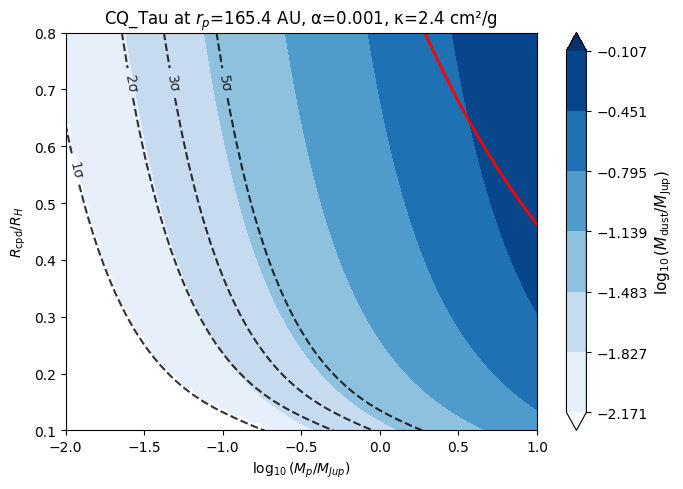

Plotting 5sigma source for CQ_Tau at radius 932.14 AU, flux=222.35 μJy, σ=40.25 μJy
Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 12.26 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 12.62 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 12.99 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 13.38 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 13.77 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 14.18 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 14.60 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 15.03 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 15.47 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 15.93 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 16.40 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 16.89 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 17

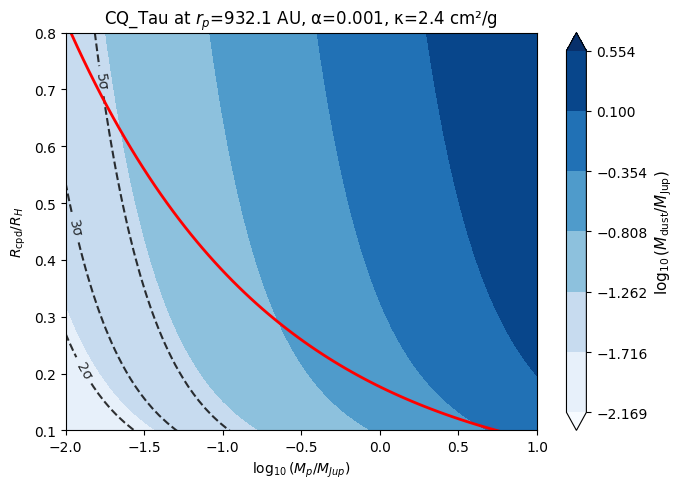

Plotting 5sigma source for DM_Tau at radius 1845.47 AU, flux=5422.67 μJy, σ=161.82 μJy
Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 35.42 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 36.47 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 37.55 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 38.66 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 39.80 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 40.98 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 42.19 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 43.44 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 44.72 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 46.05 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 47.41 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 48.81 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill =

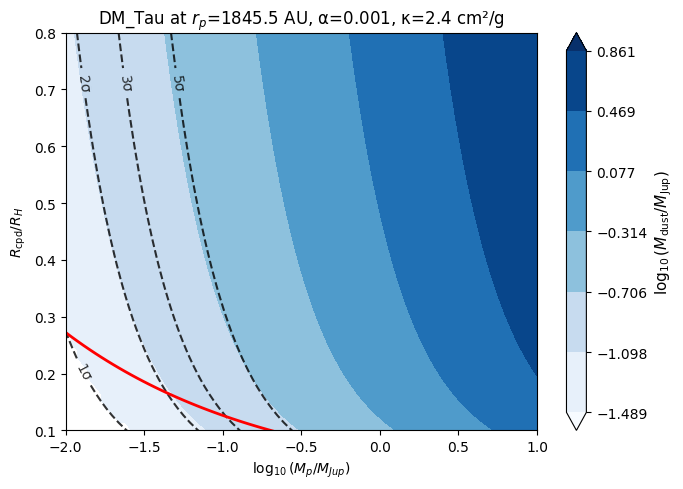

Plotting 5sigma source for V4046_Sgr at radius 837.63 AU, flux=90.54 μJy, σ=22.22 μJy
Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 10.26 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 10.57 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 10.88 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 11.20 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 11.53 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 11.87 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 12.22 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 12.59 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 12.96 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 13.34 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 13.74 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 14.14 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 

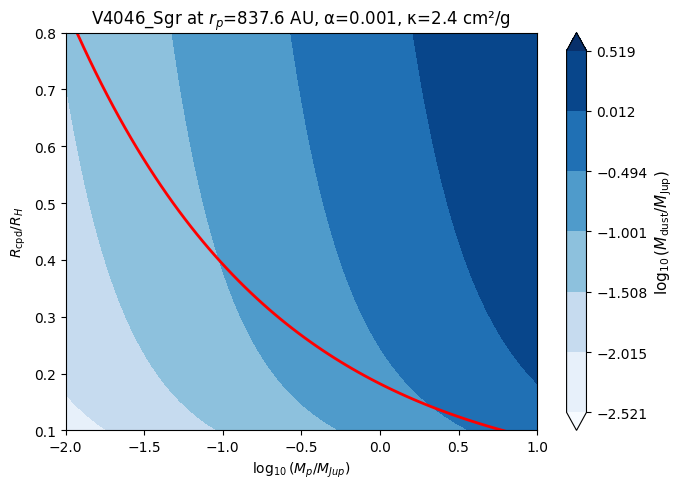

In [179]:
# Plot for 5 sigma sources
for disk_name, radius_au, flux_ujy, sigma_flux_ujy in five_sigma_sources:
    disk_params = disk_arr[disk_name]
    print(f"Plotting 5sigma source for {disk_name} at radius {radius_au} AU, flux={flux_ujy} μJy, σ={sigma_flux_ujy} μJy")
    zhu_plots_flux_map(
        target_flux_arr=[3*sigma_flux_ujy],
        disk_arr=disk_params,
        rp=radius_au,
        lam_mm=0.9,
        alpha=1e-3,
        plotmass=True,
        color='5sigsource'
    )



In [180]:
print((10/(3*1.73*1047.56))**(1/3)*837.6)

102.625333250437


# Plot for planet kink sources
### Rmb to log extra constraints posed


In [150]:

planet_kink_sources = [
    # Format: [disk_name, radius_au]
    


SyntaxError: incomplete input (2872343584.py, line 3)

In [ ]:
# Plot for planet kink sources
for disk_name, radius_au in planet_kink_sources:
    disk_params = disk_arr[disk_name]
    print(f"Plotting kink source for {disk_name} at radius {radius_au} AU")
    zhu_plots_flux_map(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_params,
        rp=radius_au,
        lam_mm=0.9,
        alpha=1e-3,
        plotmass=True,
        color='planet'
    )


In [32]:
# 


In [ ]:
from ipywidgets import interact, FloatLogSlider

def interactive_sigma6_sigma7(alpha=1e-3, Mp=1, Mdot=1e-5, kappaR=10, Rin=1, Rout=1.85, mu=2.3):
    Mp_cgs = Mp * M_jup
    Mdot_cgs = Mdot * M_jup / sec_per_yr
    Rin_cgs = Rin * R_jup
    Rout_cgs = Rout * AU

    R = np.geomspace(Rin_cgs, Rout_cgs, 100)
    term = (sigmaB * G * Mp_cgs * Mdot_cgs**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin_cgs/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)

    Omega = np.sqrt(G * Mp_cgs / R**3)
    T_ext = 10.0
    Sigma7 = (Mdot_cgs * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)

    plt.figure(figsize=(7,5))
    plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')
    plt.plot(np.log10(R/AU), np.log10(Sigma7), label=r'$\Sigma_7$ (thin)', color='r', linestyle='--')
    plt.xlabel(r'$\log_{10}(R/\mathrm{AU})$', fontsize=14)
    plt.ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$', fontsize=14)
    plt.title(f'Surface Density Prescriptions, alpha={alpha}')
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

interact(
    interactive_sigma6_sigma7,
    alpha=FloatLogSlider(value=1e-3, base=10, min=-4, max=-1, step=0.01, description='alpha'),
    Mp=FloatLogSlider(value=1, base=10, min=-2, max=1, step=0.01, description='Mp (M_jup)'),
    Mdot=FloatLogSlider(value=1e-5, base=10, min=-8, max=-3, step=0.01, description='Mdot (M_jup/yr)'),
    kappaR=(1, 100),
    Rin=(0.1, 10),
    Rout=(0.5, 10),
    mu=(1.0, 3.0)
)

interactive(children=(FloatLogSlider(value=0.001, description='alpha', max=-1.0, min=-4.0, step=0.01), FloatLo…

<function __main__.interactive_sigma6_sigma7(alpha=0.001, Mp=1, Mdot=1e-05, kappaR=10, Rin=1, Rout=1.85, mu=2.3)>

alpha only affects the amplitude of the gas density. Accretion rate affects the crossing point betweern sigma6 and sigma7

In [ ]:
# Make the plots again to streamline the process

from joblib import Parallel, delayed

def run_model(Mp, Mdot, alpha):
    out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                    mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
    if abs(out['F_nu_tot'] - target_flux) < tolerance:
        return (alpha, Mp, Mdot, out['Rout'])
    return None

results = Parallel(n_jobs=-1)(delayed(run_model)(Mp, Mdot, alpha)
                              for alpha in alpha_grid
                              for Mp in Mp_grid
                              for Mdot in Mdot_grid)
results = [r for r in results if r is not None]


